# 03 — Preprocessing and Feature Validation

Temporal split, target encoding, Spearman validation, feature selection, baseline.


In [1]:
# ── Imports + project root ─────────────────────────────────────────────────
import os, sys, re, io, pathlib, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, linregress
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
try:
    from category_encoders import TargetEncoder
except ImportError:
    TargetEncoder = None
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None
warnings.filterwarnings('ignore')

# ── Project root ───────────────────────────────────────────────────────────
_CWD = pathlib.Path(os.getcwd()).resolve()
_ROOT = _CWD
for _ in range(6):
    if (_ROOT / 'requirements.txt').exists() and (_ROOT / 'src').exists():
        break
    _ROOT = _ROOT.parent
else:
    raise RuntimeError(f'thesis_package root not found. CWD={_CWD}')

os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))
_DATA_DIR = _ROOT / 'notebooks' / 'notebooks_data'
_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── src imports ───────────────────────────────────────────────────────────────
from src.data import drop_gaps, split_mask
from src.config import SEGMENT_KEYS, RANDOM_STATE
from src.preprocessing import preprocess_features, build_seg_data_from_frames, FEATURE_COLS_BASE

# ── Global constants ──────────────────────────────────────────────────────
WAR_START    = pd.Timestamp('2022-02-24')
TRAIN_END    = pd.Timestamp('2025-04-30')
TRAIN_CUTOFF = TRAIN_END
GAP1_START   = pd.Timestamp('2025-05-01')
GAP1_END     = pd.Timestamp('2025-05-31')
VAL_START    = pd.Timestamp('2025-06-01')
VAL_END      = pd.Timestamp('2025-08-31')
GAP2_START   = pd.Timestamp('2025-09-01')
GAP2_END     = pd.Timestamp('2025-09-30')
TEST_START   = pd.Timestamp('2025-10-01')
RANDOM_STATE = 42

print(f'✅ Root        : {_ROOT}')
print(f'✅ Data dir    : {_DATA_DIR}')
print(f'✅ TRAIN_END   = {TRAIN_END.date()}')
print(f'✅ TEST_START  = {TEST_START.date()}')


✅ Root        : /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package
✅ Data dir    : /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/notebooks/notebooks_data
✅ TRAIN_END   = 2025-04-30
✅ TEST_START  = 2025-10-01


In [2]:
# ── Load feat_segments from notebook 02 ─────────────────────────────────
import pickle
_pkl = _DATA_DIR / 'feat_segments.pkl'
if not _pkl.exists():
    raise FileNotFoundError(
        f'File not found: {_pkl}\n'
        '→ First run 02_feature_engineering.ipynb (Run All)'
    )
with open(_pkl, 'rb') as f:
    _feat = pickle.load(f)

df_rent_lviv_feat = _feat[('Львів','Оренда')]
df_rent_kyiv_feat = _feat[('Київ', 'Оренда')]
df_sale_lviv_feat = _feat[('Львів','Продаж')]
df_sale_kyiv_feat = _feat[('Київ', 'Продаж')]

# ── Build df_feat (merged dataset) ─────────────────────────────────────────
_parts = []
for (city, ctype), _df in _feat.items():
    _t = _df.copy()
    _t['city']          = city
    _t['contract_type'] = ctype
    _t['segment']       = f'{city} — {ctype}'
    _parts.append(_t)

df_feat = pd.concat(_parts, ignore_index=True)
df_feat['date'] = pd.to_datetime(df_feat['date'], errors='coerce')
df_feat = drop_gaps(df_feat)

# Segment dict for preprocessing
SEG_DATASETS = {
    ('Львів','Оренда'): df_rent_lviv_feat,
    ('Київ', 'Оренда'): df_rent_kyiv_feat,
    ('Львів','Продаж'): df_sale_lviv_feat,
    ('Київ', 'Продаж'): df_sale_kyiv_feat,
}

print('✅ feat_segments loaded')
for k,v in _feat.items(): print(f'  {k}: {len(v):,} rows, {v.shape[1]} cols')
print(f'\n✅ df_feat (merged): {len(df_feat):,} rows, {df_feat.shape[1]} cols')


✅ feat_segments loaded
  ('Львів', 'Оренда'): 126,946 rows, 100 cols
  ('Київ', 'Оренда'): 193,642 rows, 100 cols
  ('Львів', 'Продаж'): 142,972 rows, 100 cols
  ('Київ', 'Продаж'): 501,172 rows, 100 cols

✅ df_feat (merged): 908,182 rows, 101 cols


## 9. Preprocessing + Temporal Split

### Splitting strategy
Since the data is a **time series**, we use a **temporal split** (not random!):

| Set | Range | Rows |
|---|---|---|
| Train | 2023-05 → 2025-04 | ~720k |
| Val   | 2025-06 → 2025-08 | ~87k |
| Test  | 2025-10 → 2026-01 | ~110k |

The model learns on the past → predicts the future. A random split would cause **data leakage**.

### Per-segment models
| Model | Target | Transformation |
|---|---|---|
| Sale model | `price_m2_usd` | `log1p` |
| Rent model | `price_uah` | `log1p` |


In [3]:

try:
    from category_encoders import TargetEncoder
except ImportError:
    TargetEncoder = None


# Use global TRAIN_END / VAL_START / TEST_START from cell 3
TRAIN_END_FE  = TRAIN_END
TEST_START_FE = TEST_START


def preprocess_features(df):
    """Leakage-free rules: yes/no and house_type mappings — on the full dataset;
    label encoding (except district) — train classes only; district → target encoding (train-only)."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    train_mask = df['date'] <= TRAIN_END_FE

    house_map = {
        'хрущовка': 'хрущовка',
        'сталінка': 'до_1960',
        'дореволюційний': 'до_1960',
        'австрійський будинок': 'до_1960',
        'польський люкс': 'до_1960',
        'польський будинок': 'до_1960',
        'радмін': 'до_1960',
        'гостинка': 'радянська_панель',
        'чеський проект': 'радянська_панель',
        'малосімейка': 'радянська_панель',
    }

    def map_house(h):
        if pd.isna(h):
            return 'unknown'
        if h in house_map:
            return house_map[h]
        hs = str(h).lower()
        if 'серія' in hs or h in ('АППС', 'АППС-люкс', 'БПС', 'серія КТ', 'серія КС', 'серія КП'):
            return 'радянська_панель'
        if 'спец' in hs:
            return 'нова_забудова'
        return 'інше'

    df['house_type_group'] = df['house_type'].apply(map_house)

    binary_cols = ['is_owner', 'has_furniture', 'has_balcony', 'has_parking', 'has_gas', 'is_babushka_renovation']
    yn_map = {'yes': 1, 'no': 0, 'unknown': np.nan}
    for col in binary_cols:
        if col in df.columns:
            df[col + '_enc'] = df[col].map(yn_map)

    cat_cols = ['city', 'wall_type', 'house_type_group', 'heating_system']
    for col in cat_cols:
        if col not in df.columns:
            continue
        enc_col = col + '_enc'
        tr_vals = df.loc[train_mask & df[col].notna(), col].astype(str)
        if tr_vals.empty:
            df[enc_col] = np.nan
            continue
        classes = np.sort(tr_vals.unique())
        le = LabelEncoder()
        le.fit(classes)
        mapping = {c: float(le.transform([c])[0]) for c in le.classes_}

        def _enc_one(v):
            if pd.isna(v):
                return np.nan
            key = str(v)
            return mapping.get(key, np.nan)

        df[enc_col] = df[col].map(_enc_one)

    if 'district' in df.columns:
        price_sale = pd.to_numeric(df.get('price_m2_usd'), errors='coerce')
        price_rent = pd.to_numeric(df.get('price_uah'), errors='coerce')
        ct = df.get('contract_type')
        if ct is not None:
            te_y = np.where(ct == 'Продаж', np.log1p(price_sale), np.log1p(price_rent))
        else:
            te_y = np.log1p(price_sale.fillna(price_rent))
        te_y = pd.Series(te_y, index=df.index)
        tr_fit = train_mask & te_y.notna() & df['district'].notna()
        if TargetEncoder is not None and tr_fit.sum() > 100:
            te = TargetEncoder(cols=['district'], smoothing=10.0)
            te.fit(df.loc[tr_fit, ['district']].astype(str), te_y.loc[tr_fit])
            df['district_te'] = te.transform(df[['district']].astype(str))['district']
        else:
            freq = df.loc[train_mask, 'district'].value_counts(normalize=True)
            df['district_te'] = df['district'].map(freq).fillna(0.0)

    return df


print('Preprocessing (train-safe category encodings)...')
df_feat = preprocess_features(df_feat)
print('Done!')

FEATURES_BASE = [
    'area_total', 'room_count', 'floor', 'floor_count',
    'floor_ratio', 'building_age', 'living_ratio', 'kitchen_ratio', 'area_per_room',
    'is_first_floor', 'is_last_floor', 'is_new_building',
    'year', 'month', 'month_sin', 'month_cos',
    'days_on_market_trend', 'is_wartime', 'post_infrastructure_attacks',
    'autonomy_score', 'amenity_score', 'amenity_count',
    'has_any_autonomy', 'autonomy_x_wartime', 'area_x_autonomy',
    'usd_uah', 'construction_idx_residential', 'construction_idx_total', 'food_price_idx',
    'dist_to_center_km', 'dist_to_transit_km', 'transit_count_1km', 'dist_to_hospital_km',
    'alert_count_month', 'alert_duration_h_month',
    'alert_days_month', 'alert_count_cumulative',
    'autonomy_x_alerts', 'newbuild_x_usd', 'shelter_x_alerts', 'log_days_x_log_usd',
    'era_ord_x_center', 'area_per_room_strict',
    'city_enc', 'district_te', 'wall_type_enc',
    'house_type_group_enc', 'heating_system_enc',
    'is_owner_enc', 'has_furniture_enc', 'has_balcony_enc',
    'has_parking_enc', 'has_gas_enc', 'is_babushka_renovation_enc',
]

FEATURES_BASE = [f for f in FEATURES_BASE if f in df_feat.columns]
print(f'Features for models: {len(FEATURES_BASE)}')
print(FEATURES_BASE)


Preprocessing (train-safe category encodings)...
Готово!
Фічей для моделей: 48
['area_total', 'room_count', 'floor', 'floor_count', 'floor_ratio', 'building_age', 'living_ratio', 'kitchen_ratio', 'area_per_room', 'is_first_floor', 'is_last_floor', 'is_new_building', 'year', 'month', 'month_sin', 'month_cos', 'is_wartime', 'autonomy_score', 'amenity_score', 'amenity_count', 'has_any_autonomy', 'autonomy_x_wartime', 'usd_uah', 'construction_idx_residential', 'construction_idx_total', 'food_price_idx', 'dist_to_center_km', 'dist_to_hospital_km', 'alert_count_month', 'alert_duration_h_month', 'alert_days_month', 'alert_count_cumulative', 'autonomy_x_alerts', 'newbuild_x_usd', 'shelter_x_alerts', 'era_ord_x_center', 'area_per_room_strict', 'city_enc', 'district_te', 'wall_type_enc', 'house_type_group_enc', 'heating_system_enc', 'is_owner_enc', 'has_furniture_enc', 'has_balcony_enc', 'has_parking_enc', 'has_gas_enc', 'is_babushka_renovation_enc']


In [4]:
# ── Three-way Temporal Split: train / val / test ─────────────────────────────
m_tr = split_mask(df_feat, 'train')
m_va = split_mask(df_feat, 'val')
m_te = split_mask(df_feat, 'test')

# ── SALE ───────────────────────────────────────────────────────────────────
sale_mask = df_feat['contract_type'] == 'Продаж'
sale_df   = df_feat[sale_mask & df_feat['price_m2_usd'].notna()].copy()
sale_df['log_price_m2_usd'] = np.log1p(sale_df['price_m2_usd'])

FEATURES_SALE = FEATURES_BASE.copy()

_tr_s = split_mask(sale_df, 'train'); _va_s = split_mask(sale_df, 'val'); _te_s = split_mask(sale_df, 'test')
X_sale_train = sale_df.loc[_tr_s, FEATURES_SALE]
X_sale_val   = sale_df.loc[_va_s, FEATURES_SALE]
X_sale_test  = sale_df.loc[_te_s, FEATURES_SALE]
y_sale_train = sale_df.loc[_tr_s, 'log_price_m2_usd']
y_sale_val   = sale_df.loc[_va_s, 'log_price_m2_usd']
y_sale_test  = sale_df.loc[_te_s, 'log_price_m2_usd']

# ── RENT ───────────────────────────────────────────────────────────────────
rent_mask = df_feat['contract_type'] == 'Оренда'
rent_df   = df_feat[rent_mask & df_feat['price_uah'].notna()].copy()
rent_df['log_price_uah'] = np.log1p(rent_df['price_uah'])

FEATURES_RENT = [f for f in FEATURES_BASE
                 if f not in ['construction_idx_residential','construction_idx_total']]

_tr_r = split_mask(rent_df, 'train'); _va_r = split_mask(rent_df, 'val'); _te_r = split_mask(rent_df, 'test')
X_rent_train = rent_df.loc[_tr_r, FEATURES_RENT]
X_rent_val   = rent_df.loc[_va_r, FEATURES_RENT]
X_rent_test  = rent_df.loc[_te_r, FEATURES_RENT]
y_rent_train = rent_df.loc[_tr_r, 'log_price_uah']
y_rent_val   = rent_df.loc[_va_r, 'log_price_uah']
y_rent_test  = rent_df.loc[_te_r, 'log_price_uah']

# ── Split statistics ──────────────────────────────────────────────────────
print('=' * 70)
print(f'  TRIPLE SPLIT   train ≤ {TRAIN_END.date()}  |  val {VAL_START.date()}→{VAL_END.date()}  |  test ≥ {TEST_START.date()}')
print(f'  GAPS (dropped) {GAP1_START.date()}→{GAP1_END.date()},  {GAP2_START.date()}→{GAP2_END.date()}')
print('=' * 70)

for name, sz in [
    ('SALE   Train', len(X_sale_train)),
    ('SALE   Val',   len(X_sale_val)),
    ('SALE   Test',  len(X_sale_test)),
    ('RENT   Train', len(X_rent_train)),
    ('RENT   Val',   len(X_rent_val)),
    ('RENT   Test',  len(X_rent_test)),
]:
    print(f'    {name:<16}: {sz:>7,}')

print(f'\n  Features SALE: {len(FEATURES_SALE)} | RENT: {len(FEATURES_RENT)}')
print(f'  Target (log)  sale  train={y_sale_train.mean():.3f}  val={y_sale_val.mean():.3f}  test={y_sale_test.mean():.3f}')
print(f'  Target (log)  rent  train={y_rent_train.mean():.3f}  val={y_rent_val.mean():.3f}  test={y_rent_test.mean():.3f}')

# Sanity: no overlap
assert not set(X_sale_train.index) & set(X_sale_val.index)
assert not set(X_sale_train.index) & set(X_sale_test.index)
assert not set(X_sale_val.index)   & set(X_sale_test.index)
assert not set(X_rent_train.index) & set(X_rent_val.index)
assert not set(X_rent_train.index) & set(X_rent_test.index)
assert not set(X_rent_val.index)   & set(X_rent_test.index)
print('\n✅ Triple split ready (assertions passed)')


  TRIPLE SPLIT   train ≤ 2025-04-30  |  val 2025-06-01→2025-08-31  |  test ≥ 2025-10-01
  GAPS (dropped) 2025-05-01→2025-05-31,  2025-09-01→2025-09-30
    ПРОДАЖ  Train   : 480,439
    ПРОДАЖ  Val     :  58,265
    ПРОДАЖ  Test    :  67,327
    ОРЕНДА  Train   : 232,908
    ОРЕНДА  Val     :  27,811
    ОРЕНДА  Test    :  41,432

  Фічей ПРОДАЖ: 48 | ОРЕНДА: 46
  Ціль (log)  sale  train=7.328  val=7.375  test=7.412
  Ціль (log)  rent  train=9.889  val=10.102  test=10.044

✅ Triple split готовий (assertion-и пройшли)


## 10. Feature validation

We use the **Spearman correlation** (robust to outliers and does not require normality).
Green = statistically significant (p < 0.05).


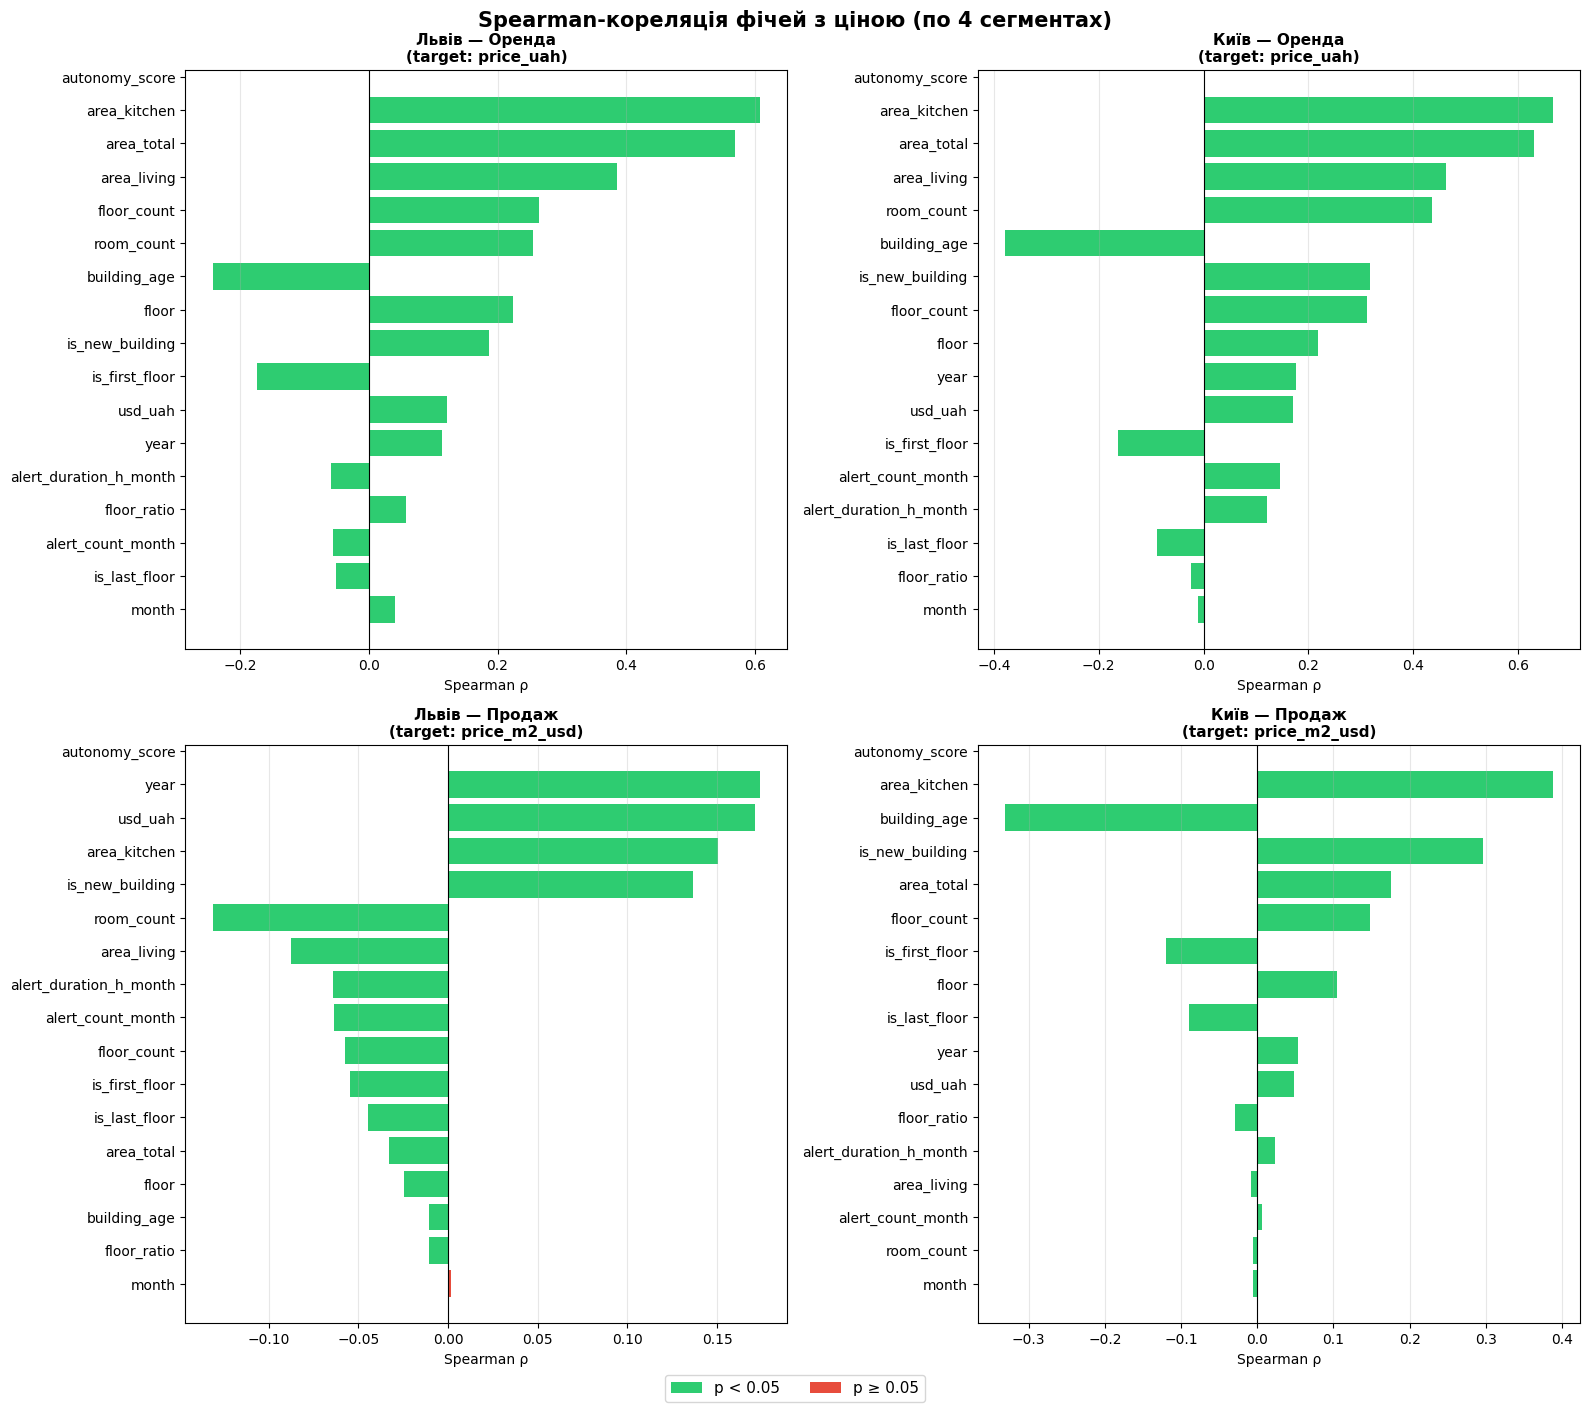

In [5]:
# ── Spearman correlation of features with price (4 segments) ───────────

NUMERIC_FEATURES = [
    'floor_ratio', 'building_age', 'area_total', 'area_living',
    'area_kitchen', 'floor', 'floor_count', 'room_count',
    'autonomy_score', 'amenity_score', 'days_since_war',
    'is_first_floor', 'is_last_floor', 'is_new_building',
    'alert_count_month', 'alert_duration_h_month', 'usd_uah',
    'year', 'month',
]

# Target configuration for df_feat
SEG_TARGETS = {
    ('Львів', 'Оренда'): 'price_uah',
    ('Київ',  'Оренда'): 'price_uah',
    ('Львів', 'Продаж'): 'price_m2_usd',
    ('Київ',  'Продаж'): 'price_m2_usd',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Spearman correlation of features with price (across 4 segments)', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

SEGS_FEAT = [
    ('Львів', 'Оренда'),
    ('Київ',  'Оренда'),
    ('Львів', 'Продаж'),
    ('Київ',  'Продаж'),
]

for i, (city, ctype) in enumerate(SEGS_FEAT):
    ax = axes_flat[i]
    target_col = SEG_TARGETS[(city, ctype)]

    mask = (df_feat['city'] == city) & (df_feat['contract_type'] == ctype)
    df_s = df_feat[mask].copy()

    if target_col not in df_s.columns or df_s[target_col].notna().sum() < 100:
        ax.text(0.5, 0.5, f'{target_col}\nN/A', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{city} — {ctype}')
        continue

    feats_exist = [f for f in NUMERIC_FEATURES if f in df_s.columns]
    target_vals = pd.to_numeric(df_s[target_col], errors='coerce')
    corrs = {}
    for feat in feats_exist:
        fv = pd.to_numeric(df_s[feat], errors='coerce')
        common = target_vals.notna() & fv.notna()
        if common.sum() < 100:
            continue
        corr, pval = spearmanr(target_vals[common], fv[common])
        corrs[feat] = {'corr': corr, 'pval': pval}

    if not corrs:
        continue

    cdf = pd.DataFrame(corrs).T.sort_values('corr', key=abs, ascending=True)
    colors_bar = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in cdf['pval']]
    ax.barh(cdf.index, cdf['corr'], color=colors_bar)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{city} — {ctype}\n(target: {target_col})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Spearman ρ', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)

fig.legend(handles=[
    Patch(facecolor='#2ecc71', label='p < 0.05'),
    Patch(facecolor='#e74c3c', label='p ≥ 0.05'),
], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('correlation_4seg.png', dpi=150, bbox_inches='tight')
plt.show()


## 10.3 Target distribution + log-transform


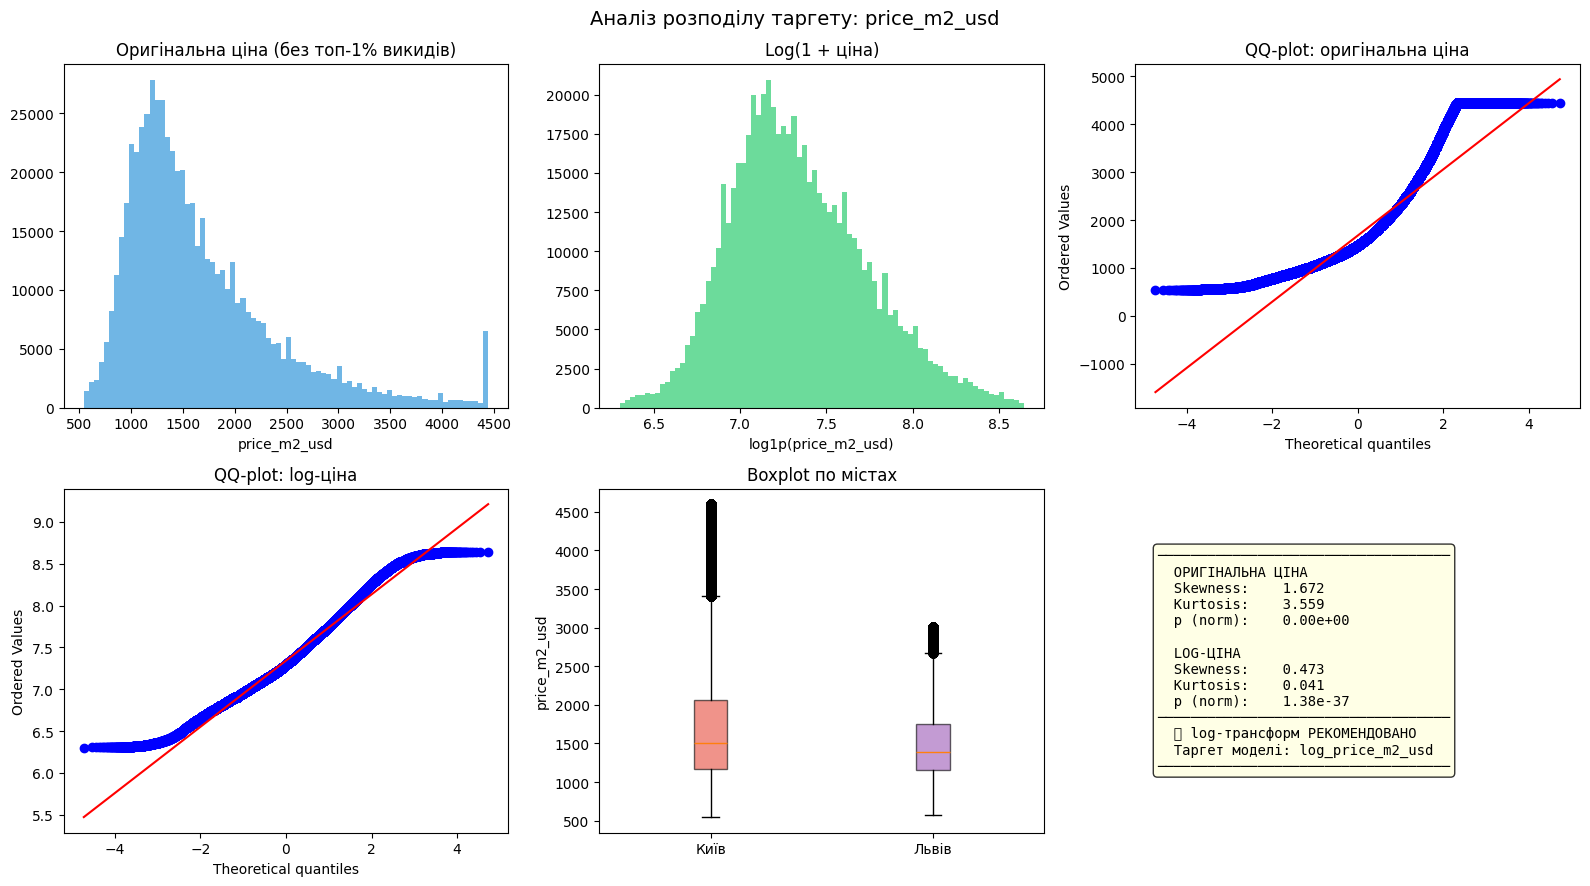

───────────────────────────────────
  ОРИГІНАЛЬНА ЦІНА
  Skewness:    1.672
  Kurtosis:    3.559
  p (norm):    0.00e+00

  LOG-ЦІНА
  Skewness:    0.473
  Kurtosis:    0.041
  p (norm):    1.38e-37
───────────────────────────────────
  ✅ log-трансформ РЕКОМЕНДОВАНО
  Таргет моделі: log_price_m2_usd
───────────────────────────────────

🎯 Фінальний таргет для моделі: 'log_price_m2_usd'


In [6]:

def analyze_target_distribution(df, target='price_m2_usd'):
    """
    Analyse the target distribution: skewness, normality, justification for log-transform.
    Critical for choosing the loss function.
    """
    series = pd.to_numeric(df[target], errors='coerce').dropna()
    log_series = np.log1p(series)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'Target distribution analysis: {target}', fontsize=14)

    # 1. Histogram of original price
    axes[0, 0].hist(series.clip(upper=series.quantile(0.99)), bins=80, color='#3498db', alpha=0.7)
    axes[0, 0].set_title('Original price (top 1% outliers removed)')
    axes[0, 0].set_xlabel(target)

    # 2. Histogram of log-price
    axes[0, 1].hist(log_series, bins=80, color='#2ecc71', alpha=0.7)
    axes[0, 1].set_title('Log(1 + price)')
    axes[0, 1].set_xlabel(f'log1p({target})')

    # 3. QQ-plot original
    stats.probplot(series.clip(upper=series.quantile(0.99)), dist='norm', plot=axes[0, 2])
    axes[0, 2].set_title('QQ-plot: original price')

    # 4. QQ-plot log-price
    stats.probplot(log_series, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('QQ-plot: log-price')

    # 5. Boxplot by city
    for city, color in [('Київ', '#e74c3c'), ('Львів', '#9b59b6')]:
        sub = pd.to_numeric(df[df['city'] == city][target], errors='coerce').dropna()
        axes[1, 1].boxplot(sub.clip(upper=sub.quantile(0.99)).values,
                           positions=[['Київ', 'Львів'].index(city) + 1],
                           patch_artist=True,
                           boxprops=dict(facecolor=color, alpha=0.6))
    axes[1, 1].set_xticks([1, 2])
    axes[1, 1].set_xticklabels(['Київ', 'Львів'])
    axes[1, 1].set_title('Boxplot by city')
    axes[1, 1].set_ylabel(target)

    # 6. Statistics
    axes[1, 2].axis('off')
    skew_orig = series.skew()
    skew_log  = log_series.skew()
    kurt_orig = series.kurtosis()
    kurt_log  = log_series.kurtosis()
    _, p_norm_orig = stats.normaltest(series.sample(min(5000, len(series)), random_state=42))
    _, p_norm_log  = stats.normaltest(log_series.sample(min(5000, len(log_series)), random_state=42))

    use_log = abs(skew_log) < abs(skew_orig)
    recommendation = '✅ log-transform RECOMMENDED' if use_log else '⚠️ log-transform does not improve'

    stats_text = (
        f"{'─'*35}\n"
        f"  ORIGINAL PRICE\n"
        f"  Skewness:    {skew_orig:.3f}\n"
        f"  Kurtosis:    {kurt_orig:.3f}\n"
        f"  p (norm):    {p_norm_orig:.2e}\n\n"
        f"  LOG-PRICE\n"
        f"  Skewness:    {skew_log:.3f}\n"
        f"  Kurtosis:    {kurt_log:.3f}\n"
        f"  p (norm):    {p_norm_log:.2e}\n"
        f"{'─'*35}\n"
        f"  {recommendation}\n"
        f"  Model target: {'log_price_m2_usd' if use_log else target}\n"
        f"{'─'*35}"
    )
    axes[1, 2].text(0.05, 0.5, stats_text, transform=axes[1, 2].transAxes,
                    fontsize=10, verticalalignment='center', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()
    print(stats_text)
    return {'use_log': use_log, 'skew_orig': skew_orig, 'skew_log': skew_log}

# Analyse target for sale
df_sale = df_feat[df_feat['contract_type'] == 'Продаж'].copy()
target_info = analyze_target_distribution(df_sale, target='price_m2_usd')
TARGET = 'log_price_m2_usd' if target_info['use_log'] else 'price_m2_usd'
print(f"\n🎯 Final model target: '{TARGET}'")


## 11. Feature selection


In [7]:

# ─────────────────────────────────────────────────────────────
# Final feature list for the model
#
# EXOGENOUS (external factors — core of H1 hypothesis):
#   Macro:    usd_uah, food_price_idx, nbu_rate
#   Time/war: days_since_war
#   Alerts:   alert_count_month (intensity), alert_count_cumulative (habituation)
#   Geo:      dist_to_center_km, dist_to_shelter_km, dist_to_subway_km (Kyiv)
#
# Removed as redundant:
#   construction_idx_residential  ← correlated with usd_uah
#   alert_duration_h_month, alert_days_month, alert_ratio  ← duplicate alert_count_month
#   dist_to_hospital_km, subway_count_1km  ← weak signal
# ─────────────────────────────────────────────────────────────
FEATURE_COLS_RAW = [
    # ── Apartment structure ─────────────────────────────────
    'room_count', 'area_total', 'area_living', 'area_kitchen',
    'floor', 'floor_count', 'floor_ratio', 'is_first_floor', 'is_last_floor',
    'ceiling_height',
    # ── Building ────────────────────────────────────────────
    'building_age', 'is_new_building', 'built_year',
    # ── Autonomy (war-specific hedonic feature) ─────────────
    'autonomy_score', 'autonomy_heat', 'autonomy_power', 'autonomy_water', 'autonomy_net',
    # ── Amenities ───────────────────────────────────────────
    'has_furniture', 'has_balcony', 'has_parking', 'has_gas', 'amenity_score',
    # ── Renovation ──────────────────────────────────────────
    'is_without_renovation', 'is_babushka_renovation',
    # ── Time ────────────────────────────────────────────────
    'year', 'month', 'quarter',
    # ── EXOGENOUS: Macro ───────────────────────────────────
    'usd_uah',           # USD rate — direct driver of sale market
    'food_price_idx',    # inflationary pressure on rent in UAH
    'nbu_rate',          # interest rate — cost of capital / mortgages
    # ── EXOGENOUS: Time/War ─────────────────────────────────
    'days_since_war',    # long-term adaptation trend
    # ── EXOGENOUS: Alerts ───────────────────────────────────
    'alert_count_month',      # current monthly threat intensity
    'alert_count_cumulative', # cumulative effect (habituation)
    # ── EXOGENOUS: Geospatial ───────────────────────────────
    'dist_to_center_km',   # classical hedonic — distance to centre
    'dist_to_shelter_km',  # war-specific — distance to shelter
    'dist_to_subway_km',   # transport access (Kyiv — metro, Lviv — tram)
]

# Keep only those present in at least one of the 4 datasets
_all_cols = set()
for _df in [df_rent_lviv_feat, df_rent_kyiv_feat, df_sale_lviv_feat, df_sale_kyiv_feat]:
    _all_cols.update(_df.columns)

FEATURE_COLS = [f for f in FEATURE_COLS_RAW if f in _all_cols]
print(f"✅ Features selected: {len(FEATURE_COLS)}")

# Convenient print by group
_exo_keys = {'usd_uah', 'food_price_idx', 'nbu_rate', 'days_since_war',
              'alert_count_month', 'alert_count_cumulative',
              'dist_to_center_km', 'dist_to_shelter_km', 'dist_to_subway_km'}
exo = [f for f in FEATURE_COLS if f in _exo_keys]
hedonic = [f for f in FEATURE_COLS if f not in _exo_keys]
print(f"  Hedonic    ({len(hedonic)}): {hedonic}")
print(f"  Exogenous  ({len(exo)}):  {exo}")


✅ Фічей відібрано: 36
  Гедонічні (28): ['room_count', 'area_total', 'area_living', 'area_kitchen', 'floor', 'floor_count', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'ceiling_height', 'building_age', 'is_new_building', 'built_year', 'autonomy_score', 'autonomy_heat', 'autonomy_power', 'autonomy_water', 'autonomy_net', 'has_furniture', 'has_balcony', 'has_parking', 'has_gas', 'amenity_score', 'is_without_renovation', 'is_babushka_renovation', 'year', 'month', 'quarter']
  Екзогенні  (8):  ['usd_uah', 'food_price_idx', 'nbu_rate', 'alert_count_month', 'alert_count_cumulative', 'dist_to_center_km', 'dist_to_shelter_km', 'dist_to_subway_km']


## 12. Baseline — segment median


In [8]:

def evaluate_model(y_true, y_pred, model_name='Model', use_log=True):
    """
    Computes model quality metrics.
    If use_log=True — converts back via expm1 for interpretable RMSE/MAE.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # MAPE — relative error (in original price space)
    if use_log:
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-9))) * 100

    print(f"\n{'─'*40}")
    print(f"  {model_name}")
    print(f"{'─'*40}")
    print(f"  MAE  (log):  {mae:.4f}")
    print(f"  RMSE (log):  {rmse:.4f}")
    print(f"  R²:          {r2:.4f}")
    print(f"  MAPE (orig): {mape:.2f}%")
    print(f"{'─'*40}")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE_%': mape}


def baseline_median_segment(df_train, df_test, target, segment_col='segment'):
    """
    Baseline: predicts the train-median of the target per segment.
    Falls back to the global median if a segment is unseen.
    """
    segment_medians = df_train.groupby(segment_col)[target].median()
    global_median   = df_train[target].median()

    df_test = df_test.copy()
    df_test['baseline_pred'] = df_test[segment_col].map(segment_medians).fillna(global_median)
    return df_test['baseline_pred']


# Build df_train / df_test with segment
df_sale = df_feat[df_feat['contract_type'] == 'Продаж'].copy()
df_sale[TARGET] = pd.to_numeric(df_sale[TARGET], errors='coerce')
df_sale['date'] = pd.to_datetime(df_sale['date'], errors='coerce')
df_sale = df_sale.dropna(subset=[TARGET, 'date', 'segment'])

df_train_full = df_sale[df_sale['date'] <= '2024-12-31']
df_test_full  = df_sale[df_sale['date'] >  '2024-12-31']

# Baseline prediction
baseline_preds = baseline_median_segment(df_train_full, df_test_full, TARGET)

# Evaluation
use_log = TARGET.startswith('log')
baseline_metrics = evaluate_model(
    df_test_full[TARGET], baseline_preds,
    model_name='Baseline (segment median)',
    use_log=use_log
)

print(f"\n💡 This is our minimum quality bar — the ML model must beat these metrics.")



────────────────────────────────────────
  Baseline (медіана сегменту)
────────────────────────────────────────
  MAE  (log):  0.3242
  RMSE (log):  0.4137
  R²:          -0.0615
  MAPE (orig): 29.92%
────────────────────────────────────────

💡 Це наш мінімальний поріг якості — ML-модель має перевищити ці метрики.


## 13. Per-segment analysis (4 segments)

Lviv — Rent | Lviv — Sale | Kyiv — Rent | Kyiv — Sale


In [9]:


def to_binary_series(s):
    if s.dtype == object or s.dtype.name == "category":
        s = s.astype(str).str.lower().str.strip()
        s = s.map(
            {
                "true": 1,
                "false": 0,
                "yes": 1,
                "no": 0,
                "1": 1,
                "0": 0,
                "1.0": 1,
                "0.0": 0,
                "nan": np.nan,
            }
        )
    return pd.to_numeric(s, errors="coerce")


def _map_house_type_group(h):
    """Same logic as map_house in preprocess_features (house-type grouping)."""
    house_map = {
        "хрущовка": "хрущовка",
        "сталінка": "до_1960",
        "дореволюційний": "до_1960",
        "австрійський будинок": "до_1960",
        "польський люкс": "до_1960",
        "польський будинок": "до_1960",
        "радмін": "до_1960",
        "гостинка": "радянська_панель",
        "чеський проект": "радянська_панель",
        "малосімейка": "радянська_панель",
    }
    if pd.isna(h):
        return "невідомо"
    if h in house_map:
        return house_map[h]
    hs = str(h).lower()
    if "серія" in hs or h in ("АППС", "АППС-люкс", "БПС", "серія КТ", "серія КС", "серія КП"):
        return "радянська_панель"
    if "спец" in hs:
        return "нова_забудова"
    return "інше"


def _add_train_only_category_codes(df, train_mask, raw_col, enc_col):
    """Encode categories using train classes only (test unknown -> NaN)."""
    if raw_col not in df.columns:
        return
    tr_vals = df.loc[train_mask, raw_col].dropna()
    if tr_vals.empty:
        df[enc_col] = np.nan
        return
    cats = sorted(tr_vals.astype(str).unique())
    mapping = {c: float(i) for i, c in enumerate(cats)}

    def _code(x):
        if pd.isna(x):
            return np.nan
        key = str(x)
        return mapping.get(key, np.nan)

    df[enc_col] = df[raw_col].map(_code)


_BINARY_PREP = [
    "autonomy_heat",
    "autonomy_power",
    "autonomy_water",
    "autonomy_net",
    "has_furniture",
    "has_balcony",
    "has_parking",
    "has_gas",
    "is_without_renovation",
    "is_babushka_renovation",
    "is_owner",
    "is_new_building",
    "is_first_floor",
    "is_last_floor",
]

_FEATS_PREP = [
    "room_count",
    "area_total",
    "area_living",
    "area_kitchen",
    "floor",
    "floor_count",
    "floor_ratio",
    "is_first_floor",
    "is_last_floor",
    "ceiling_height",
    "building_age",
    "is_new_building",
    "built_year",
    "autonomy_score",
    "autonomy_heat",
    "autonomy_power",
    "autonomy_water",
    "autonomy_net",
    "has_furniture",
    "has_balcony",
    "has_parking",
    "has_gas",
    "amenity_score",
    "is_without_renovation",
    "is_babushka_renovation",
    "year",
    "month",
    "quarter",
    "days_since_war",
    "usd_uah",
    "construction_idx_residential",
    "food_price_idx",
    "nbu_rate",
    "dist_to_center_km",
    "dist_to_hospital_km",
    "dist_to_shelter_km",
    "dist_to_subway_km",
    "subway_count_1km",
    "alert_count_month",
    "alert_duration_h_month",
    "alert_days_month",
    "alert_count_cumulative",
    "alert_ratio",
    # Location and house type (train-only encodings below)
    "city_enc",
    "district_enc",
    "microdistrict_enc",
    "wall_type_enc",
    "heating_system_enc",
    "house_type_group_enc",
]

_SEG_CFG_PREP = {
    ("Львів", "Оренда"): {"target": "price_uah", "label": "Львів — Оренда", "currency": "UAH/міс"},
    ("Київ", "Оренда"): {"target": "price_uah", "label": "Київ — Оренда", "currency": "UAH/міс"},
    ("Львів", "Продаж"): {"target": "price_m2_usd", "label": "Львів — Продаж", "currency": "USD/м²"},
    ("Київ", "Продаж"): {"target": "price_m2_usd", "label": "Київ — Продаж", "currency": "USD/м²"},
}


# NOTE: build_seg_data_from_frames is (re)defined in the next cell with
# extended logic (district target-encoding + MICE). The stub below is kept
# only so this cell still exposes the helper symbols used elsewhere.

print("✅ Helper functions build_seg_data_from_frames / to_binary_series loaded")


✅ Допоміжні функції build_seg_data_from_frames / to_binary_series завантажено


In [10]:

try:
    from category_encoders import TargetEncoder as _TargetEncoder
except ImportError:
    _TargetEncoder = None


def to_binary_series(s):
    if s.dtype == object or s.dtype.name == "category":
        s = s.astype(str).str.lower().str.strip()
        s = s.map(
            {
                "true": 1,
                "false": 0,
                "yes": 1,
                "no": 0,
                "1": 1,
                "0": 0,
                "1.0": 1,
                "0.0": 0,
                "nan": np.nan,
            }
        )
    return pd.to_numeric(s, errors="coerce")


def _map_house_type_group(h):
    """Same logic as map_house in preprocess_features (house-type grouping)."""
    house_map = {
        "хрущовка": "хрущовка",
        "сталінка": "до_1960",
        "дореволюційний": "до_1960",
        "австрійський будинок": "до_1960",
        "польський люкс": "до_1960",
        "польський будинок": "до_1960",
        "радмін": "до_1960",
        "гостинка": "радянська_панель",
        "чеський проект": "радянська_панель",
        "малосімейка": "радянська_панель",
    }
    if pd.isna(h):
        return "невідомо"
    if h in house_map:
        return house_map[h]
    hs = str(h).lower()
    if "серія" in hs or h in ("АППС", "АППС-люкс", "БПС", "серія КТ", "серія КС", "серія КП"):
        return "радянська_панель"
    if "спец" in hs:
        return "нова_забудова"
    return "інше"


def _add_train_only_category_codes(df, train_mask, raw_col, enc_col):
    """Encode categories using train classes only (test unknown -> NaN)."""
    if raw_col not in df.columns:
        return
    tr_vals = df.loc[train_mask, raw_col].dropna()
    if tr_vals.empty:
        df[enc_col] = np.nan
        return
    cats = sorted(tr_vals.astype(str).unique())
    mapping = {c: float(i) for i, c in enumerate(cats)}

    def _code(x):
        if pd.isna(x):
            return np.nan
        key = str(x)
        return mapping.get(key, np.nan)

    df[enc_col] = df[raw_col].map(_code)


_BINARY_PREP = [
    "autonomy_heat",
    "autonomy_power",
    "autonomy_water",
    "autonomy_net",
    "has_furniture",
    "has_balcony",
    "has_parking",
    "has_gas",
    "is_without_renovation",
    "is_babushka_renovation",
    "is_owner",
    "is_new_building",
    "is_first_floor",
    "is_last_floor",
]

_FEATS_PREP = [
    "room_count",
    "area_total",
    "area_living",
    "area_kitchen",
    "floor",
    "floor_count",
    "floor_ratio",
    "is_first_floor",
    "is_last_floor",
    "ceiling_height",
    "building_age",
    "is_new_building",
    "built_year",
    "autonomy_score",
    "autonomy_heat",
    "autonomy_power",
    "autonomy_water",
    "autonomy_net",
    "has_furniture",
    "has_balcony",
    "has_parking",
    "has_gas",
    "amenity_score",
    "is_without_renovation",
    "is_babushka_renovation",
    "year",
    "month",
    "quarter",
    "days_since_war",
    "usd_uah",
    "construction_idx_residential",
    "food_price_idx",
    "nbu_rate",
    "dist_to_center_km",
    "dist_to_hospital_km",
    "dist_to_shelter_km",
    "dist_to_subway_km",
    "subway_count_1km",
    "alert_count_month",
    "alert_duration_h_month",
    "alert_days_month",
    "alert_count_cumulative",
    "alert_ratio",
    "is_wartime",
    "autonomy_x_alerts",
    "autonomy_x_wartime",
    "newbuild_x_usd",
    "shelter_x_alerts",
    "log_days_x_log_usd",
    "era_ord_x_center",
    "area_per_room_strict",
    # Location and house type (train-only encodings below)
    "city_enc",
    "district_te",
    "microdistrict_enc",
    "wall_type_enc",
    "heating_system_enc",
    "house_type_group_enc",
]

_SEG_CFG_PREP = {
    ("Львів", "Оренда"): {"target": "price_uah", "label": "Львів — Оренда", "currency": "UAH/міс"},
    ("Київ", "Оренда"): {"target": "price_uah", "label": "Київ — Оренда", "currency": "UAH/міс"},
    ("Львів", "Продаж"): {"target": "price_m2_usd", "label": "Львів — Продаж", "currency": "USD/м²"},
    ("Київ", "Продаж"): {"target": "price_m2_usd", "label": "Київ — Продаж", "currency": "USD/м²"},
}


def build_seg_data_from_frames(seg_datasets: dict, train_cutoff: str = "2024-12-31", val_cutoff: str = "2024-09-30"):
    """Prepare 4 segments: NaN medians from train only + location categories (train-only encoding).
    train: date <= val_cutoff, val: val_cutoff < date <= train_cutoff, test: date > train_cutoff."""
    cutoff = pd.Timestamp(train_cutoff)
    v_cutoff = pd.Timestamp(val_cutoff)
    _all_cols = set()
    for _d in seg_datasets.values():
        _all_cols.update(_d.columns)

    sd, cfg = {}, {}
    for (city, ctype), ccfg in _SEG_CFG_PREP.items():
        cfg[(city, ctype)] = ccfg
        df = seg_datasets[(city, ctype)].copy()
        target = ccfg["target"]
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df[target] = pd.to_numeric(df[target], errors="coerce")

        for col in _BINARY_PREP:
            if col in df.columns:
                df[col] = to_binary_series(df[col])

        if "house_type" in df.columns:
            df["house_type_group"] = df["house_type"].apply(_map_house_type_group)

        df = df.dropna(subset=[target, "date"])
        train_mask = df["date"] <= cutoff

        _CAT_PAIRS = [
            ("city", "city_enc"),
            ("microdistrict", "microdistrict_enc"),
            ("wall_type", "wall_type_enc"),
            ("heating_system", "heating_system_enc"),
            ("house_type_group", "house_type_group_enc"),
        ]
        for raw, enc in _CAT_PAIRS:
            _add_train_only_category_codes(df, train_mask, raw, enc)

        if "district" in df.columns:
            tr = df.loc[train_mask]
            y_log = np.log1p(pd.to_numeric(tr[target], errors="coerce"))
            ok = y_log.notna() & tr["district"].notna()
            if _TargetEncoder is not None and ok.sum() > 50:
                te = _TargetEncoder(cols=["district"], smoothing=10.0)
                te.fit(tr.loc[ok, ["district"]].astype(str), y_log.loc[ok])
                df["district_te"] = te.transform(df[["district"]].astype(str))["district"]
            else:
                freq = df.loc[train_mask, "district"].value_counts(normalize=True)
                df["district_te"] = df["district"].map(freq).fillna(0.0)

        feats = [f for f in _FEATS_PREP if f in df.columns]
        avail = [f for f in feats if f in df.columns]
        for col in avail:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        num_f = [c for c in avail if pd.api.types.is_numeric_dtype(df[c])]

        tr = df[df["date"] <= v_cutoff].copy()
        va = df[(df["date"] > v_cutoff) & (df["date"] <= cutoff)].copy()
        te = df[df["date"] > cutoff].copy()
        if len(tr) == 0 or len(te) == 0:
            sd[(city, ctype)] = None
            continue
        # ── MICE imputation (fit on TRAIN only, leakage-safe) ──────────────

        # Inf → NaN first
        for _fr in [tr, va, te]:
            _fr[num_f] = _fr[num_f].replace([np.inf, -np.inf], np.nan)

        # Binary cols (absence = 0) — fill directly, no regression needed
        _bin_pfx = ('autonomy_', 'has_', 'is_')
        _bin_num  = [c for c in num_f if any(c.startswith(p) for p in _bin_pfx)]
        _cont_num = [c for c in num_f if c not in _bin_num]
        for _fr in [tr, va, te]:
            _fr[_bin_num] = _fr[_bin_num].fillna(0.0)

        # Add missingness indicators BEFORE imputation
        _cols_miss = [c for c in _cont_num if tr[c].isna().any()]
        for c in _cols_miss:
            _ind = f'{c}_missing'
            tr[_ind] = tr[c].isna().astype(float)
            va[_ind] = va[c].isna().astype(float)
            te[_ind] = te[c].isna().astype(float)
            if _ind not in num_f:
                num_f = num_f + [_ind]

        # Drop cols that are entirely NaN in TRAIN (can't be imputed from data)
        _cols_miss = [c for c in _cols_miss if tr[c].notna().any()]

        # MICE on continuous cols with actual missingness
        if _cols_miss:
            _n_miss = len(_cols_miss)
            _n_fit  = min(15_000, len(tr))
            _idx_fit = (tr.sample(_n_fit, random_state=RANDOM_STATE).index
                        if len(tr) > _n_fit else tr.index)
            # np.column_stack → shape (rows, _n_miss); avoids pandas dup-col issues
            _Xfit = np.column_stack(
                [pd.to_numeric(tr.loc[_idx_fit, _c], errors='coerce').values
                 for _c in _cols_miss]
            ).astype(float)
            _mice = IterativeImputer(
                max_iter=10, initial_strategy='median',
                n_nearest_features=(min(10, _n_miss) if _n_miss > 1 else None),
                random_state=RANDOM_STATE,
            )
            _mice.fit(_Xfit)
            for _fr in [tr, va, te]:
                _Xfr = np.column_stack(
                    [pd.to_numeric(_fr[_c], errors='coerce').values
                     for _c in _cols_miss]
                ).astype(float)
                _arr = _mice.transform(_Xfr)
                # Safe single-column assignment (never list-assign)
                for _ci, _cn in enumerate(_cols_miss):
                    _fr[_cn] = _arr[:, _ci]

        # Safety fallback — any residual NaN → 0
        for _fr in [tr, va, te]:
            _fr[num_f] = _fr[num_f].fillna(0.0)

        # dtype guarantee — re-coerce any object columns (pandas 2.x / None values)
        for _fr in [tr, va, te]:
            for _c in num_f:
                if _fr[_c].dtype == object:
                    _fr[_c] = pd.to_numeric(_fr[_c], errors='coerce').fillna(0.0)
        loc_feats = [c for c in num_f if c.endswith("_enc") or c == "district_te"]
        print(
            f"  [{ccfg['label']}] n_features={len(num_f)} | train={len(tr):,} val={len(va):,} test={len(te):,} | *_enc: {loc_feats}"
        )
        sd[(city, ctype)] = {
            "X_train": tr[num_f],
            "X_val":   va[num_f],
            "X_test":  te[num_f],
            "y_train": tr[target],
            "y_val":   va[target],
            "y_test":  te[target],
            "df_train": tr,
            "df_val":   va,
            "df_test":  te,
            "features": num_f,
            "target": target,
            "label": ccfg["label"],
        }
    return sd, cfg


print("✅ Helper functions build_seg_data_from_frames / to_binary_series loaded")


✅ Допоміжні функції build_seg_data_from_frames / to_binary_series завантажено


In [11]:

# ── 4-segment dictionary ──────────────────────────────────────────────────────
SEG_DATASETS = {
    ('Львів', 'Оренда'): df_rent_lviv_feat,
    ('Київ',  'Оренда'): df_rent_kyiv_feat,
    ('Львів', 'Продаж'): df_sale_lviv_feat,
    ('Київ',  'Продаж'): df_sale_kyiv_feat,
}

PRICE_CANDIDATES = ['price_m2_usd', 'price_uah', 'price_usd']

print("=" * 70)
print("DATA OVERVIEW BY 4 SEGMENTS")
print("=" * 70)

for (city, ctype), df_s in SEG_DATASETS.items():
    label = f"{city} — {ctype}"
    print(f"\n{'─'*60}")
    print(f"  {label}  ({len(df_s):,} rows)")
    if len(df_s) == 0:
        print("  ⚠️ EMPTY SEGMENT!"); continue
    dates = pd.to_datetime(df_s['date'], errors='coerce')
    print(f"  Dates: {dates.min().date()} → {dates.max().date()}")
    train_n = (dates <= '2024-12-31').sum()
    test_n  = (dates >  '2024-12-31').sum()
    print(f"  Train: {train_n:,}  |  Test: {test_n:,}")
    for col in PRICE_CANDIDATES:
        if col in df_s.columns:
            nn  = df_s[col].notna().sum()
            pct = nn / len(df_s) * 100
            med = df_s[col].dropna().median()
            print(f"    {col:<22}: {nn:,} non-null ({pct:.0f}%)  median={med:.1f}")

print("\n✅ Diagnostics complete.")

# seg_data is built in the models section via build_seg_data_from_frames(SEG_DATASETS)


ОГЛЯД ДАНИХ ПО 4 СЕГМЕНТАХ

────────────────────────────────────────────────────────────
  Львів — Оренда  (126,946 рядків)
  Дати:  2023-05-25 → 2026-01-24
  Train: 87,032  |  Test: 39,914
    price_m2_usd          : 121,087 non-null (95%)  медіана=8.4
    price_uah             : 126,946 non-null (100%)  медіана=17237.0
    price_usd             : 126,946 non-null (100%)  медіана=440.4

────────────────────────────────────────────────────────────
  Київ — Оренда  (193,642 рядків)
  Дати:  2023-05-25 → 2026-01-24
  Train: 107,181  |  Test: 86,461
    price_m2_usd          : 193,640 non-null (100%)  медіана=9.4
    price_uah             : 193,642 non-null (100%)  медіана=21000.0
    price_usd             : 193,642 non-null (100%)  медіана=521.5

────────────────────────────────────────────────────────────
  Львів — Продаж  (142,972 рядків)
  Дати:  2023-05-25 → 2026-01-24
  Train: 85,440  |  Test: 57,532
    price_m2_usd          : 142,972 non-null (100%)  медіана=1388.9
    price_uah  

In [12]:
# ─────────────────────────────────────────────────────────────
# 5.1  CONFIGURATION — target and parameters for each segment
#      After diagnostics we pick the correct target
# ─────────────────────────────────────────────────────────────

# CHANGE HERE if a different target is needed after diagnostics
SEG_CONFIG = {
    ('Львів', 'Оренда'): {
        'target':   'price_uah',        # monthly rent
        'use_log':  False,
        'label':    'Lviv — Rent',
        'currency': 'UAH/mo',
    },
    ('Львів', 'Продаж'): {
        'target':   'price_m2_usd',     # price per m² in USD
        'use_log':  False,
        'label':    'Lviv — Sale',
        'currency': 'USD/m²',
    },
    ('Київ', 'Оренда'): {
        'target':   'price_uah',
        'use_log':  False,
        'label':    'Kyiv — Rent',
        'currency': 'UAH/mo',
    },
    ('Київ', 'Продаж'): {
        'target':   'price_m2_usd',
        'use_log':  False,
        'label':    'Kyiv — Sale',
        'currency': 'USD/m²',
    },
}

TRAIN_CUTOFF = '2024-12-31'

print("✅ Segment configuration:")
for (city, ctype), cfg in SEG_CONFIG.items():
    print(f"  {cfg['label']}: target='{cfg['target']}', use_log={cfg['use_log']}")


✅ Конфігурація сегментів:
  Львів — Оренда: target='price_uah', use_log=False
  Львів — Продаж: target='price_m2_usd', use_log=False
  Київ — Оренда: target='price_uah', use_log=False
  Київ — Продаж: target='price_m2_usd', use_log=False


In [13]:
BINARY_COLS = [
    'autonomy_heat', 'autonomy_power', 'autonomy_water', 'autonomy_net',
    'has_furniture', 'has_balcony', 'has_parking', 'has_gas',
    'is_without_renovation', 'is_babushka_renovation', 'is_owner',
    'is_new_building', 'is_first_floor', 'is_last_floor',
    'is_wartime',
]

def to_binary(series):
    s = series.copy()
    if s.dtype == object or s.dtype.name == 'category':
        s = s.astype(str).str.lower().str.strip()
        s = s.map({'true':1,'false':0,'yes':1,'no':0,'1':1,'0':0,'1.0':1,'0.0':0,'nan':np.nan})
    return pd.to_numeric(s, errors='coerce')


def _add_district_target_encoding(df, train_mask, target_col, smoothing=10.0):
    """
    Target encoding for 'district' — fit on TRAIN ONLY, transform on the whole df.
    Uses log1p(target) for numerical stability.
    Returns (df, was_added: bool).
    """
    if 'district' not in df.columns:
        return df, False
    y_log = np.log1p(pd.to_numeric(df[target_col], errors='coerce'))
    ok = train_mask & y_log.notna() & df['district'].notna()
    if ok.sum() < 50:
        return df, False  # not enough data for encoding

    if TargetEncoder is not None:
        te = TargetEncoder(cols=['district'], smoothing=smoothing)
        te.fit(df.loc[ok, ['district']].astype(str), y_log.loc[ok])
        df['district_te'] = te.transform(df[['district']].astype(str))['district']
    else:
        # fallback: smoothed group-mean encoder (without category_encoders)
        grp = y_log.loc[ok].groupby(df.loc[ok, 'district'].astype(str))
        g_mean = grp.mean()
        g_cnt = grp.count()
        global_mean = y_log.loc[ok].mean()
        smoothed = (g_cnt * g_mean + smoothing * global_mean) / (g_cnt + smoothing)
        df['district_te'] = df['district'].astype(str).map(smoothed)

    # test may have unseen districts → fill with train-median of district_te
    fill_val = df.loc[train_mask, 'district_te'].median()
    df['district_te'] = df['district_te'].fillna(fill_val)
    return df, True


def prepare_segment(df_seg, target, feature_cols, label='', train_cutoff='2024-12-31'):
    """
    Prepare X_train/X_test/y_train/y_test for a single segment.
    df_seg — pre-filtered dataset (one city, one contract type).
    Target is log-transformed (log1p) inside the models.
    """
    df = df_seg.copy()
    df['date']   = pd.to_datetime(df['date'], errors='coerce')
    df[target]   = pd.to_numeric(df[target],  errors='coerce')

    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = to_binary(df[col])

    df = df.dropna(subset=[target, 'date'])
    cutoff = pd.Timestamp(train_cutoff)
    train_mask = df['date'] <= cutoff

    # ── District target encoding (fit on TRAIN ONLY — prevents leak) ──
    df, has_te = _add_district_target_encoding(df, train_mask, target)

    effective_feats = list(feature_cols)
    if has_te and 'district_te' not in effective_feats:
        effective_feats.append('district_te')

    available = [f for f in effective_feats if f in df.columns]
    for col in available:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    numeric_feats = [c for c in available if pd.api.types.is_numeric_dtype(df[c])]

    # ── MICE imputation (fit on TRAIN only) ──────────────────────────────
    df[numeric_feats] = df[numeric_feats].replace([np.inf, -np.inf], np.nan)
    _bin_pfx67 = ('autonomy_', 'has_', 'is_')
    _bin67  = [c for c in numeric_feats if any(c.startswith(p) for p in _bin_pfx67)]
    _cont67 = [c for c in numeric_feats if c not in _bin67]
    df[_bin67] = df[_bin67].fillna(0.0)
    # Drop cols entirely NaN in TRAIN — imputer has nothing to fit on
    _miss67 = [c for c in _cont67
               if df.loc[train_mask, c].isna().any()
               and df.loc[train_mask, c].notna().any()]
    if _miss67:
        _n67 = len(_miss67)
        _Xtr67 = np.column_stack(
            [pd.to_numeric(df.loc[train_mask, _c], errors='coerce').values
             for _c in _miss67]
        ).astype(float)
        _Xal67 = np.column_stack(
            [pd.to_numeric(df[_c], errors='coerce').values for _c in _miss67]
        ).astype(float)
        _mice67 = IterativeImputer(
            max_iter=10, initial_strategy='median',
            n_nearest_features=(min(10, _n67) if _n67 > 1 else None),
            random_state=42,
        )
        _mice67.fit(_Xtr67)
        _arr67 = _mice67.transform(_Xal67)
        # Safe single-column assignment
        for _ci67, _cn67 in enumerate(_miss67):
            df[_cn67] = _arr67[:, _ci67]
    df[numeric_feats] = df[numeric_feats].fillna(0.0)

    # dtype guarantee — re-coerce any object columns surviving pandas 2.x CoW / None values
    for _c in numeric_feats:
        if df[_c].dtype == object:
            df[_c] = pd.to_numeric(df[_c], errors='coerce').fillna(0.0)

    df_train = df.loc[train_mask].copy()
    df_test  = df.loc[~train_mask].copy()

    te_tag = ' [+district_te]' if has_te else ' [NO district]'
    print()
    print('  [' + label + ']')
    print('    Rows: {:,}  |  Features: {}{}'.format(len(df), len(numeric_feats), te_tag))
    print('    Train:  {:,}  |  Test: {:,}'.format(len(df_train), len(df_test)))

    if len(df_train) == 0 or len(df_test) == 0:
        print('    ⚠️ Train or Test is empty!')
        return None

    return {
        'X_train':  df_train[numeric_feats],
        'X_test':   df_test[numeric_feats],
        'y_train':  df_train[target],
        'y_test':   df_test[target],
        'df_train': df_train,
        'df_test':  df_test,
        'features': numeric_feats,
        'target':   target,
        'label':    label,
    }


# ── Run for all 4 segments ─────────────────────────────
print('=' * 60)
print('DATA PREPARATION FOR 4 SEGMENTS')
print('=' * 60)


_FEAT_INLINE = [
    # ── Base hedonic ──
    'room_count',
    'area_total',
    'area_living',
    'area_kitchen',
    'floor',
    'floor_count',
    'floor_ratio',
    'is_first_floor',
    'is_last_floor',
    'ceiling_height',
    'building_age',
    'is_new_building',
    'built_year',
    # ── Autonomy / amenities ──
    'autonomy_score',
    'autonomy_heat',
    'autonomy_power',
    'autonomy_water',
    'autonomy_net',
    'has_furniture',
    'has_balcony',
    'has_parking',
    'has_gas',
    'amenity_score',
    'is_without_renovation',
    'is_babushka_renovation',
    # ── Temporal ──
    'year',
    'month',
    'quarter',
    'days_since_war',
    # ── Macro ──
    'usd_uah',
    'construction_idx_residential',
    'food_price_idx',
    'nbu_rate',
    # ── Location ──
    'dist_to_center_km',
    'dist_to_hospital_km',
    'dist_to_shelter_km',
    'dist_to_subway_km',
    'subway_count_1km',
    # ── Alerts / security ──
    'alert_count_month',
    'alert_duration_h_month',
    'alert_days_month',
    'alert_count_cumulative',
    'alert_ratio',
    # ── H1 INTERACTIONS (CRITICAL for A/B/C hypothesis) ──
    'is_wartime',
    'autonomy_x_alerts',
    'autonomy_x_wartime',
    'newbuild_x_usd',
    'shelter_x_alerts',
    'log_days_x_log_usd',
    'era_ord_x_center',
    'area_per_room_strict',
    # ── Spatial + temporal lag (train-only) ──
    'knn_price_m2',
    'district_month_median',
]

seg_data = {}
for (city, ctype), cfg in SEG_CONFIG.items():
    result = prepare_segment(
        df_seg=SEG_DATASETS[(city, ctype)],
        target=cfg['target'],
        feature_cols=_FEAT_INLINE,
        label=cfg['label'],
        train_cutoff=TRAIN_CUTOFF,
    )
    seg_data[(city, ctype)] = result

ok = sum(1 for v in seg_data.values() if v is not None)
print('\n✅ Done: {}/4 segments prepared'.format(ok))


ПІДГОТОВКА ДАНИХ ДЛЯ 4 СЕГМЕНТІВ

  [Львів — Оренда]
    Рядків: 126,946  |  Фічей: 51 [+district_te]
    Train:  87,032  |  Test: 39,914

  [Львів — Продаж]
    Рядків: 142,972  |  Фічей: 51 [+district_te]
    Train:  85,440  |  Test: 57,532

  [Київ — Оренда]
    Рядків: 193,642  |  Фічей: 51 [+district_te]
    Train:  107,181  |  Test: 86,461

  [Київ — Продаж]
    Рядків: 501,172  |  Фічей: 51 [+district_te]
    Train:  323,414  |  Test: 177,758

✅ Готово: 4/4 сегментів підготовлено


## 14. Models (Ridge / RF / XGB / LightGBM / MLP)

Four models are trained separately for each of the 4 segments.

**Target:** `log1p(price)` — distribution stabilisation; MAE/RMSE/MAPE are computed in the **original units** after `expm1`.

**Temporal split:** train ≤ `TRAIN_END` (pre-2025), val — 2025-06→08, test ≥ 2025-10.

**Baselines:** `Ridge(alpha=1.0)` + Random Forest + XGBoost + **LightGBM (GOSS)** + MLP.


## 14.0 Rolling-origin CV (walk-forward)

Stability assessment of metrics over multiple time windows (vs. a single split).


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# ROLLING-ORIGIN (walk-forward) CV — FPP3 §5.10
# 4 sequential folds instead of a single split to assess stability over time.
# ─────────────────────────────────────────────────────────────────────────────

def _coerce_numeric_frame(df, cols):
    """Cast all columns to float. yes/no/true/false/unknown → 1/0/NaN."""
    out = {}
    yn_map = {'yes': 1.0, 'true': 1.0, '1': 1.0, '1.0': 1.0,
              'no': 0.0, 'false': 0.0, '0': 0.0, '0.0': 0.0,
              'unknown': np.nan, 'nan': np.nan, '': np.nan, 'none': np.nan}
    for c in cols:
        s = df[c]
        if s.dtype == object or str(s.dtype).startswith('category'):
            s2 = s.astype(str).str.strip().str.lower().map(yn_map)
            out[c] = pd.to_numeric(s2, errors='coerce')
        else:
            out[c] = pd.to_numeric(s, errors='coerce')
    return pd.DataFrame(out, index=df.index)


def rolling_origin_evaluate(df_seg, target, feature_cols, model_factory, folds, label=''):
    df = df_seg.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df.dropna(subset=['date', target])

    feats = [c for c in feature_cols if c in df.columns]
    rows = []
    for i, (tr_end, va_end) in enumerate(folds, 1):
        tr = df[df['date'] <= tr_end]
        va = df[(df['date'] > tr_end) & (df['date'] <= va_end)]
        if len(tr) < 500 or len(va) < 100:
            continue
        X_tr_raw = _coerce_numeric_frame(tr, feats)
        X_va_raw = _coerce_numeric_frame(va, feats)
        # ── MICE imputation (light version for CV speed) ────────────────
        X_tr_raw = X_tr_raw.replace([np.inf, -np.inf], np.nan)
        X_va_raw = X_va_raw.replace([np.inf, -np.inf], np.nan)
        _bin_pfx70 = ('autonomy_', 'has_', 'is_')
        _bin70  = [c for c in feats if c in X_tr_raw.columns
                   and any(c.startswith(p) for p in _bin_pfx70)]
        _cont70 = [c for c in feats if c in X_tr_raw.columns and c not in _bin70]
        X_tr_raw[_bin70] = X_tr_raw[_bin70].fillna(0.0)
        X_va_raw[_bin70] = X_va_raw[_bin70].fillna(0.0)
        _miss70 = [c for c in _cont70
                   if X_tr_raw[c].isna().any() and X_tr_raw[c].notna().any()]
        if _miss70:
            _n70 = len(_miss70)
            _Xtr70 = np.column_stack(
                [pd.to_numeric(X_tr_raw[_c], errors='coerce').values for _c in _miss70]
            ).astype(float)
            _mice70 = IterativeImputer(
                max_iter=5, initial_strategy='median',
                n_nearest_features=(min(10, _n70) if _n70 > 1 else None),
                random_state=42,
            )
            _mice70.fit(_Xtr70)
            for _Xr70 in [X_tr_raw, X_va_raw]:
                _a70 = _mice70.transform(np.column_stack(
                    [pd.to_numeric(_Xr70[_c], errors='coerce').values for _c in _miss70]
                ).astype(float))
                for _ci70, _cn70 in enumerate(_miss70):
                    _Xr70[_cn70] = _a70[:, _ci70]
        # dtype guarantee before fillna
        for _Xraw in [X_tr_raw, X_va_raw]:
            for _c in _Xraw.columns:
                if _Xraw[_c].dtype == object:
                    _Xraw[_c] = pd.to_numeric(_Xraw[_c], errors='coerce')
        X_tr = X_tr_raw.fillna(0.0)
        X_va = X_va_raw.fillna(0.0)
        y_tr = np.log1p(tr[target].values)
        y_va = va[target].values

        # StandardScaler — required for Ridge on differently-scaled features
        from sklearn.pipeline import Pipeline
        base = model_factory()
        if base.__class__.__name__ == 'Ridge':
            model = Pipeline([('scaler', StandardScaler()), ('est', base)])
        else:
            model = base
        model.fit(X_tr, y_tr)
        y_pred = np.expm1(model.predict(X_va))

        mae  = mean_absolute_error(y_va, y_pred)
        rmse = np.sqrt(mean_squared_error(y_va, y_pred))
        mape = 100.0 * np.mean(np.abs((y_va - y_pred) / (y_va + 1e-9)))
        rows.append({
            'fold': i, 'train_end': tr_end.date(), 'val_end': va_end.date(),
            'n_train': len(tr), 'n_val': len(va),
            'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE%': round(mape, 2),
        })
    res = pd.DataFrame(rows)
    if len(res):
        print(f"\n[{label}]")
        print(res.to_string(index=False))
        print(f"  mean MAPE: {res['MAPE%'].mean():.2f}%  |  std: {res['MAPE%'].std():.2f}%")
    return res


ROLL_FOLDS = [
    (pd.Timestamp('2024-06-30'), pd.Timestamp('2024-12-31')),
    (pd.Timestamp('2024-09-30'), pd.Timestamp('2025-03-31')),
    (pd.Timestamp('2024-12-31'), pd.Timestamp('2025-06-30')),
    (pd.Timestamp('2025-06-30'), pd.Timestamp('2026-01-31')),
]

if 'SEG_DATASETS' in globals() and 'SEG_CONFIG' in globals():
    print("=" * 68)
    print("ROLLING-ORIGIN CV — Ridge baseline across all 4 segments")
    print("=" * 68)
    # Dedupe: _FEAT_INLINE already includes the H1 interactions below
    _extra = ['is_wartime', 'autonomy_x_alerts', 'autonomy_x_wartime', 'newbuild_x_usd',
              'shelter_x_alerts', 'log_days_x_log_usd', 'era_ord_x_center', 'area_per_room_strict']
    _base = _FEAT_INLINE if '_FEAT_INLINE' in globals() else []
    _roll_feats = list(dict.fromkeys(list(_base) + _extra))
    roll_results = {}
    for (city, ctype), df_seg in SEG_DATASETS.items():
        cfg = SEG_CONFIG[(city, ctype)]
        roll_results[(city, ctype)] = rolling_origin_evaluate(
            df_seg=df_seg, target=cfg['target'],
            feature_cols=_roll_feats,
            model_factory=lambda: Ridge(alpha=1.0, random_state=RANDOM_STATE),
            folds=ROLL_FOLDS, label=cfg['label'],
        )
else:
    print("⚠️ Skipped: SEG_DATASETS/SEG_CONFIG not yet defined.")


ROLLING-ORIGIN CV — Ridge baseline на всіх 4 сегментах

[Львів — Оренда]
 fold  train_end    val_end  n_train  n_val     MAE    RMSE  MAPE%
    1 2024-06-30 2024-12-31    64969  22063 3923.10 5546.83  22.25
    2 2024-09-30 2025-03-31    76433  22621 3656.91 6534.02  19.93
    3 2024-12-31 2025-06-30    87032  24081 3806.25 6808.03  19.65
    4 2025-06-30 2026-01-31   111113  15833 6906.19 9868.81  31.36
  mean MAPE: 23.30%  |  std: 5.50%

[Київ — Оренда]
 fold  train_end    val_end  n_train  n_val     MAE     RMSE  MAPE%
    1 2024-06-30 2024-12-31    79067  28114 8451.92 14594.82  23.65
    2 2024-09-30 2025-03-31    92300  31738 8299.32 14913.07  25.48
    3 2024-12-31 2025-06-30   107181  33736 8215.47 15029.03  23.74
    4 2025-06-30 2026-01-31   140917  52725 9721.72 17503.16  32.01
  mean MAPE: 26.22%  |  std: 3.95%

[Львів — Продаж]
 fold  train_end    val_end  n_train  n_val    MAE   RMSE  MAPE%
    1 2024-06-30 2024-12-31    59801  25639 361.53 459.85  26.42
    2 2024-09-30 

## 13.5 Hyperparameter tuning (Grid Search on VAL)

For each model we tune structural parameters on the val set.
Results are stored in `best_params` and used in the training below.


In [15]:
# ── Hardcoded best_params (grid search on VAL, 50 min, one-off) ────────────
# No need to re-run src/tuning.py — results are fixed below.

best_params = {
    'rf': {
        ('Львів', 'Оренда'): {'min_samples_leaf': 3, 'max_features': 0.8},
        ('Київ',  'Оренда'): {'min_samples_leaf': 3, 'max_features': 0.6},
        ('Львів', 'Продаж'): {'min_samples_leaf': 3, 'max_features': 0.8},
        ('Київ',  'Продаж'): {'min_samples_leaf': 3, 'max_features': 0.8},
    },
    'xgb': {
        # max_depth=8, subsample=0.75 everywhere; min_child_weight varies between rent/sale
        # n_estimators determined by early stopping during training (10_000 cap)
        ('Львів', 'Оренда'): {'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.75},
        ('Київ',  'Оренда'): {'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.75},
        ('Львів', 'Продаж'): {'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.75},
        ('Київ',  'Продаж'): {'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.75},
    },
    'lgbm': {
        # num_leaves=255 everywhere (grid max); n_estimators — early stopping
        ('Львів', 'Оренда'): {'num_leaves': 255, 'min_child_samples': 20, 'n_estimators': 4035},
        ('Київ',  'Оренда'): {'num_leaves': 255, 'min_child_samples': 20, 'n_estimators': 5010},
        ('Львів', 'Продаж'): {'num_leaves': 255, 'min_child_samples': 20, 'n_estimators': 5998},
        ('Київ',  'Продаж'): {'num_leaves': 255, 'min_child_samples': 20, 'n_estimators': 6000},
    },
    'mlp': {
        # (512,256,128) wins everywhere; lr varies by segment
        ('Львів', 'Оренда'): {'hidden_layer_sizes': (512, 256, 128), 'learning_rate_init': 5e-4},
        ('Київ',  'Оренда'): {'hidden_layer_sizes': (512, 256, 128), 'learning_rate_init': 1e-3},
        ('Львів', 'Продаж'): {'hidden_layer_sizes': (512, 256, 128), 'learning_rate_init': 1e-3},
        ('Київ',  'Продаж'): {'hidden_layer_sizes': (512, 256, 128), 'learning_rate_init': 5e-4},
    },
}

print("✅ best_params loaded (grid search on VAL, fixed)")
for model, segs in best_params.items():
    print(f"  {model.upper()}: {len(segs)} segments")


✅ best_params завантажено (grid search на VAL, зафіксовано)
  RF: 4 сегменти
  XGB: 4 сегменти
  LGBM: 4 сегменти
  MLP: 4 сегменти


In [16]:
# ── Save seg_data for notebook 04 ─────────────────────────────────────
import pickle
_out = _DATA_DIR / 'seg_data.pkl'
with open(_out, 'wb') as f:
    pickle.dump({
        'seg_data':    seg_data,
        'SEG_CONFIG':  SEG_CONFIG,
        'SEG_DATASETS': SEG_DATASETS,
        'best_params': best_params,
    }, f)
print(f'✅ Saved → {_out}')


✅ Збережено → /Users/veronikacharnosh/Desktop/Thesis/thesis vs code/thesis_package/notebooks/notebooks_data/seg_data.pkl
